In [ ]:
!pip install transformers pandas torch scikit-learn
!pip install nltk spacy word2number
!python -m spacy download en_core_web_sm
!pip install -U transformers

  Preparing metadata (setup.py) ... done
  Created wheel for word2number: filename=word2number-1.1-py3-none-any.whl size=5568 sha256=9669e9c4bba165dec35cb3e3e5cccc3cc6c85dee4cf5e17fd204588ab97e1f97
  Stored in directory: /root/.cache/pip/wheels/5b/79/fb/d25928e599c7e11fe4e00d32048cd74933f34a74c633d2aea6
Successfully built word2number
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 146.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,2.377170,0.157895,0.162000,0.157895,0.105244
2,2.559300,2.330254,0.221805,0.342472,0.221805,0.169970
3,2.489900,2.123998,0.466165,0.530031,0.466165,0.447192
4,2.136400,1.321944,0.646617,0.620199,0.646617,0.594149
5,2.136400,0.799379,0.774436,0.782148,0.774436,0.749337
6,1.278000,0.602218,0.812030,0.819795,0.812030,0.786581
7,0.822200,0.482959,0.864662,0.858423,0.864662,0.849589
8,0.569700,0.405610,0.875940,0.867841,0.875940,0.861490
9,0.493800,0.359294,0.906015,0.906165,0.906015,0.898603
10,0.493800,0.307309,0.917293,0.917303,0.917293,0.909532


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than w

Validation Results:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


{'eval_loss': 0.17596860229969025, 'eval_accuracy': 0.9511278195488722, 'eval_precision': 0.9523968982145674, 'eval_recall': 0.9511278195488722, 'eval_f1': 0.9495830312396785, 'eval_runtime': 0.8081, 'eval_samples_per_second': 329.175, 'eval_steps_per_second': 21.038, 'epoch': 30.0}

Testing Results:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


              precision    recall  f1-score   support

           A       0.94      0.97      0.95        32
           F       0.87      0.85      0.86        39
          FT       1.00      1.00      1.00        31
           L       0.97      1.00      0.98        31
          LF       0.87      0.97      0.92        35
          MN       0.91      1.00      0.95        30
           O       1.00      0.44      0.62         9
          PE       1.00      0.38      0.55         8
          SC       0.97      1.00      0.98        32
          SE       0.67      1.00      0.80        10
          US       0.83      0.50      0.62        10

    accuracy                           0.91       267
   macro avg       0.91      0.83      0.84       267
weighted avg       0.92      0.91      0.91       267



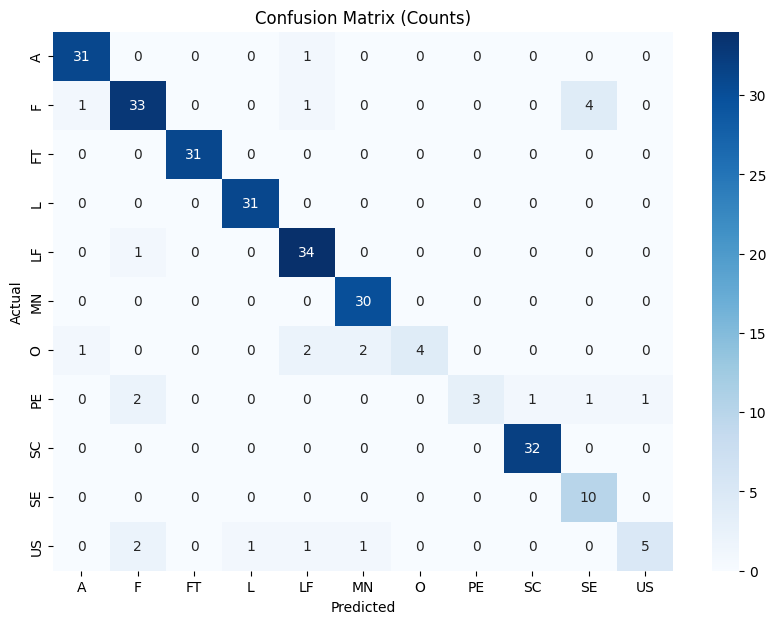

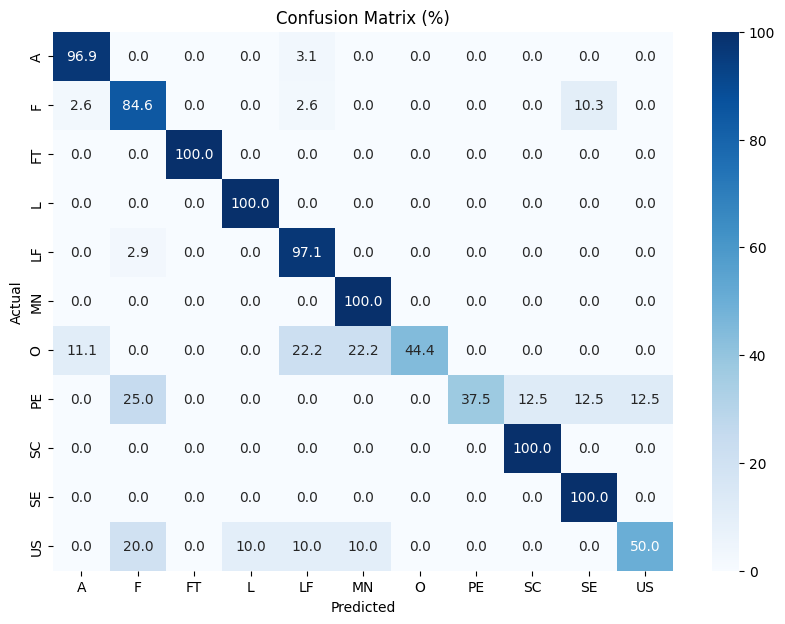

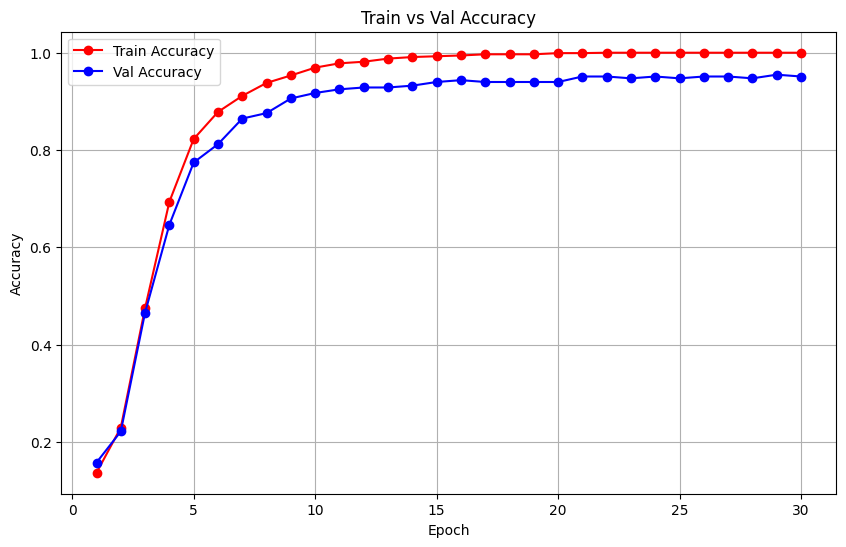

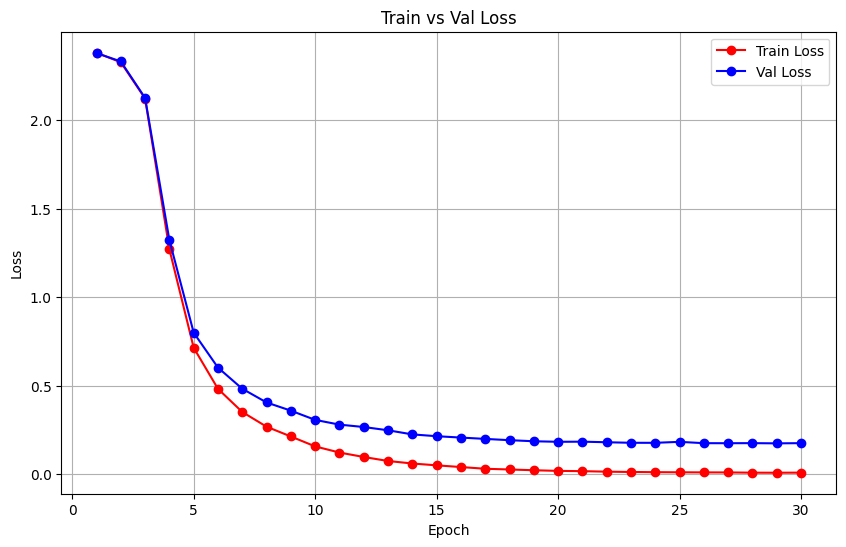

In [ ]:
# --- Imports ---
import os
import random
import re
import string
from nltk.corpus import stopwords, wordnet
import nltk
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report, confusion_matrix
from transformers import (BertTokenizer, RobertaTokenizer, Trainer, TrainingArguments,
                          EarlyStoppingCallback, BertModel, RobertaModel, TrainerCallback)
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Setup ---
os.environ["WANDB_DISABLED"] = "true"
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))

# --- Text Processing ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ").lower()
            if synonym != word:
                synonyms.add(synonym)
    return list(synonyms)

def synonym_replacement(text, n=1):
    words = text.split()
    new_words = words.copy()
    random_word_list = list(set([word for word in words if word not in stop_words and len(word) > 3]))
    random.shuffle(random_word_list)
    num_replaced = 0
    for random_word in random_word_list:
        synonyms = get_synonyms(random_word)
        if len(synonyms) >= 1:
            synonym = random.choice(synonyms)
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break
    return ' '.join(new_words)

def phrase_insertion(text, n=1):
    phrases = ["the system shall", "must be able to", "should ensure that"]
    words = text.split()
    for _ in range(n):
        add_phrase = random.choice(phrases)
        random_idx = random.randint(0, len(words)-1)
        words.insert(random_idx, add_phrase)
    return ' '.join(words)

def text_simplification(text):
    text = re.sub(r'\bthe system shall\b', '', text)
    text = re.sub(r'\bmust be able to\b', '', text)
    text = re.sub(r'\bshould ensure that\b', '', text)
    return text.strip()

def random_deletion(text, p=0.1):
    words = text.split()
    if len(words) == 1:
        return text
    remaining = [word for word in words if random.random() > p]
    return ' '.join(remaining) if remaining else random.choice(words)

def random_swap(text, n=1):
    words = text.split()
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

# --- Data Loading ---
DATA_URL = 'https://raw.githubusercontent.com/egbertbritannia-cpu/rbl-requirements-classification/main/data/exp/promise_exp.csv'
data_path = DATA_URL

df = pd.read_csv(data_path)
print(f"Loaded PROMISE expanded dataset from: {data_path}")
df['cleaned_text'] = df['RequirementText'].apply(clean_text)
df = df[df['class'].map(df['class'].value_counts()) > 1]

# --- Augmentation ---
augmentation_targets = {'FT': 200, 'L': 200, 'MN': 200, 'A': 200, 'CS': 200, 'LF': 200, 'SC': 200, 'PO':200}
augmented = []

for cls, min_required in augmentation_targets.items():
    class_df = df[df['class'] == cls]
    needed = max(0, min_required - len(class_df))
    if len(class_df) == 0 or needed == 0:
        continue
    multiplier = needed // len(class_df) + 1
    for _, row in class_df.iterrows():
        for _ in range(multiplier):
            text = row['cleaned_text']
            aug_text = synonym_replacement(text, 1)
            aug_text = phrase_insertion(aug_text, 1)
            aug_text = text_simplification(aug_text)
            aug_text = random_swap(aug_text, 1)
            aug_text = random_deletion(aug_text, p=0.1)
            augmented.append({'RequirementText': row['RequirementText'], 'cleaned_text': aug_text, 'class': cls})

df_aug = pd.DataFrame(augmented)
df_combined = pd.concat([df, df_aug], ignore_index=True)

# --- Label Encoding & Split ---
texts = df_combined['cleaned_text'].tolist()
labels = LabelEncoder().fit_transform(df_combined['class'])
label_encoder = LabelEncoder()
label_encoder.fit(df_combined['class'])

train_texts, val_test_texts, train_labels, val_test_labels = train_test_split(texts, labels, test_size=0.3, stratify=labels, random_state=42)
val_texts, test_texts, val_labels, test_labels = train_test_split(val_test_texts, val_test_labels, test_size=0.5, stratify=val_test_labels, random_state=42)

# --- Tokenization ---
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

def tokenize(tokenizer, texts):
    return tokenizer(texts, truncation=True, padding=True, max_length=128)

bert_train_enc = tokenize(bert_tokenizer, train_texts)
roberta_train_enc = tokenize(roberta_tokenizer, train_texts)
bert_val_enc = tokenize(bert_tokenizer, val_texts)
roberta_val_enc = tokenize(roberta_tokenizer, val_texts)
bert_test_enc = tokenize(bert_tokenizer, test_texts)
roberta_test_enc = tokenize(roberta_tokenizer, test_texts)

# --- Dataset ---
class HybridDataset(Dataset):
    def __init__(self, bert_enc, roberta_enc, labels):
        self.bert = bert_enc
        self.roberta = roberta_enc
        self.labels = labels

    def __getitem__(self, idx):
        return {
            'bert_input_ids': torch.tensor(self.bert['input_ids'][idx]),
            'bert_attention_mask': torch.tensor(self.bert['attention_mask'][idx]),
            'roberta_input_ids': torch.tensor(self.roberta['input_ids'][idx]),
            'roberta_attention_mask': torch.tensor(self.roberta['attention_mask'][idx]),
            'labels': torch.tensor(self.labels[idx])
        }

    def __len__(self):
        return len(self.labels)

train_dataset = HybridDataset(bert_train_enc, roberta_train_enc, train_labels)
val_dataset = HybridDataset(bert_val_enc, roberta_val_enc, val_labels)
test_dataset = HybridDataset(bert_test_enc, roberta_test_enc, test_labels)

# Model
class HybridBertRobertaClassifier(torch.nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.roberta = RobertaModel.from_pretrained('roberta-base')
        self.dropout = torch.nn.Dropout(0.5)
        self.bert_reduce = torch.nn.Linear(768, 256)
        self.roberta_reduce = torch.nn.Linear(768, 256)
        self.batchnorm = torch.nn.BatchNorm1d(512)
        self.classifier = torch.nn.Linear(512, num_labels, bias=False)

        for name, param in self.bert.named_parameters():
            if name.startswith("encoder.layer.") and int(name.split(".")[2]) < 8:
                param.requires_grad = False
        for name, param in self.roberta.named_parameters():
            if name.startswith("encoder.layer.") and int(name.split(".")[2]) < 8:
                param.requires_grad = False

    def forward(self, bert_input_ids, bert_attention_mask, roberta_input_ids, roberta_attention_mask, labels=None):
        bert_output = self.bert(input_ids=bert_input_ids, attention_mask=bert_attention_mask).pooler_output
        roberta_output = self.roberta(input_ids=roberta_input_ids, attention_mask=roberta_attention_mask).pooler_output
        x = torch.cat([self.bert_reduce(self.dropout(bert_output)), self.roberta_reduce(self.dropout(roberta_output))], dim=1)
        x = self.batchnorm(x)
        logits = self.classifier(x)
        loss = torch.nn.CrossEntropyLoss()(logits, labels) if labels is not None else None
        return {'loss': loss, 'logits': logits} if loss is not None else {'logits': logits}

# Collator
def hybrid_collator(batch):
    return {
        'bert_input_ids': torch.stack([x['bert_input_ids'] for x in batch]),
        'bert_attention_mask': torch.stack([x['bert_attention_mask'] for x in batch]),
        'roberta_input_ids': torch.stack([x['roberta_input_ids'] for x in batch]),
        'roberta_attention_mask': torch.stack([x['roberta_attention_mask'] for x in batch]),
        'labels': torch.stack([x['labels'] for x in batch])
    }

# Metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}

# Accuracy tracking
class AccuracyPlotCallback(TrainerCallback):
    def __init__(self):
        self.train_accuracies = []
        self.val_accuracies = []
        self.train_losses = []
        self.val_losses = []

    def on_epoch_end(self, args, state, control, **kwargs):
        train_metrics = trainer.evaluate(train_dataset)
        val_metrics = trainer.evaluate(val_dataset)
        self.train_accuracies.append(train_metrics["eval_accuracy"])
        self.val_accuracies.append(val_metrics["eval_accuracy"])
        self.train_losses.append(train_metrics["eval_loss"])
        self.val_losses.append(val_metrics["eval_loss"])

accuracy_callback = AccuracyPlotCallback()

# Training
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=30,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_ratio=0.1,
    weight_decay=0.02,
    learning_rate=1e-5,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    gradient_accumulation_steps=2,
    fp16=True,
    dataloader_num_workers=4,
    report_to="none",
    max_grad_norm=1.0,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = HybridBertRobertaClassifier(num_labels=len(label_encoder.classes_)).to(device)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=hybrid_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2), accuracy_callback]
)

trainer.train()

# Evaluation
print("Validation Results:")
eval_results = trainer.evaluate(val_dataset)
print(eval_results)

print("\nTesting Results:")
test_results = trainer.predict(test_dataset)
test_preds = test_results.predictions.argmax(-1)
print(classification_report(test_labels, test_preds, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Counts)")
plt.show()

cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix (%)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Accuracy/Loss plots
epochs = range(1, len(accuracy_callback.train_accuracies)+1)
plt.figure(figsize=(10, 6))
plt.plot(epochs, accuracy_callback.train_accuracies, 'r-o', label='Train Accuracy')
plt.plot(epochs, accuracy_callback.val_accuracies, 'b-o', label='Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Val Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(epochs, accuracy_callback.train_losses, 'r-o', label='Train Loss')
plt.plot(epochs, accuracy_callback.val_losses, 'b-o', label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Val Loss")
plt.legend()
plt.grid()
plt.show()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.620900,2.492529,0.083095,0.082802,0.083095,0.066848
2,2.598600,2.403580,0.243553,0.332733,0.243553,0.221356
3,2.413800,1.968111,0.538682,0.559743,0.538682,0.508380
4,1.809200,1.073256,0.742120,0.743693,0.742120,0.714483
5,1.190800,0.775767,0.793696,0.775785,0.793696,0.764347
6,0.915900,0.637637,0.828080,0.799804,0.828080,0.804076
7,0.726400,0.552312,0.856734,0.827862,0.856734,0.838311
8,0.620600,0.484128,0.859599,0.864244,0.859599,0.844119
9,0.518300,0.454555,0.882521,0.887454,0.882521,0.873379
10,0.447700,0.413424,0.891117,0.887810,0.891117,0.883444


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than w

Validation Results:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


{'eval_loss': 0.2805763781070709, 'eval_accuracy': 0.9226361031518625, 'eval_precision': 0.9209203446140913, 'eval_recall': 0.9226361031518625, 'eval_f1': 0.9203233961266323, 'eval_runtime': 1.0978, 'eval_samples_per_second': 317.903, 'eval_steps_per_second': 20.04, 'epoch': 30.0}

Testing Results:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


              precision    recall  f1-score   support

           A       0.91      1.00      0.96        32
           F       0.91      0.92      0.92        66
          FT       0.94      0.97      0.96        33
           L       0.97      1.00      0.98        32
          LF       0.97      0.95      0.96        37
          MN       0.92      1.00      0.96        33
           O       1.00      0.58      0.74        12
          PE       0.88      0.70      0.78        10
          PO       0.97      0.97      0.97        30
          SC       0.94      1.00      0.97        33
          SE       0.85      0.89      0.87        19
          US       0.88      0.58      0.70        12

    accuracy                           0.93       349
   macro avg       0.93      0.88      0.90       349
weighted avg       0.93      0.93      0.93       349



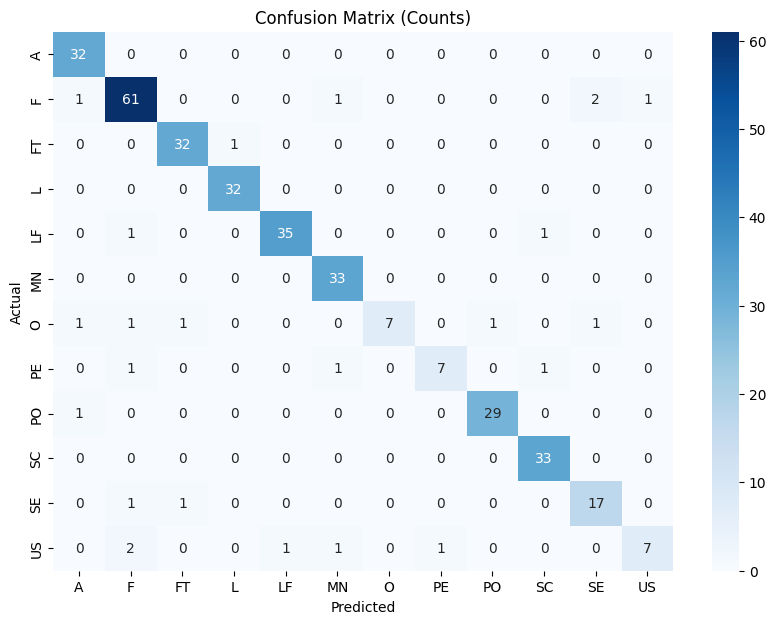

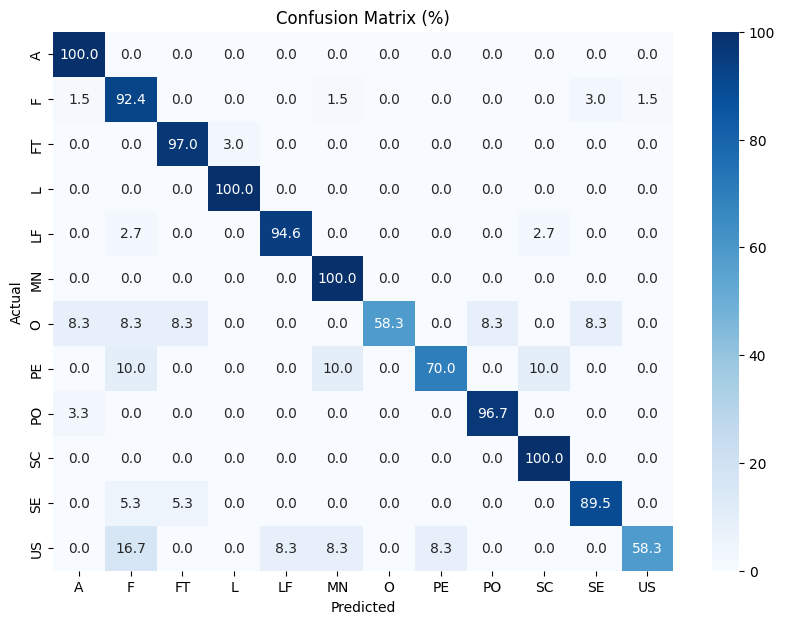

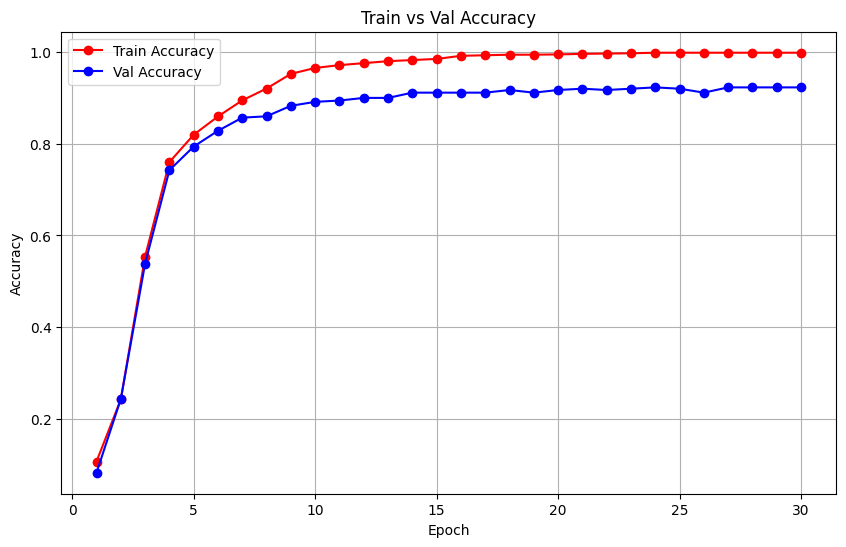

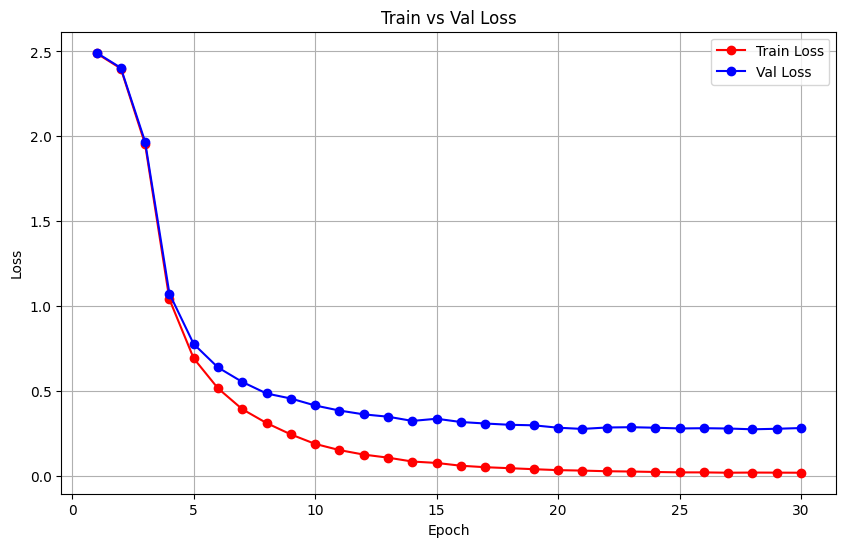

In [ ]:
# --- Imports ---
import os
import random
import re
import string
from nltk.corpus import stopwords, wordnet
import nltk
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report, confusion_matrix
from transformers import (BertTokenizer, RobertaTokenizer, Trainer, TrainingArguments,
                          EarlyStoppingCallback, BertModel, RobertaModel, TrainerCallback)
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Setup ---
os.environ["WANDB_DISABLED"] = "true"
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))

# --- Text Processing ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ").lower()
            if synonym != word:
                synonyms.add(synonym)
    return list(synonyms)

def synonym_replacement(text, n=1):
    words = text.split()
    new_words = words.copy()
    random_word_list = list(set([word for word in words if word not in stop_words and len(word) > 3]))
    random.shuffle(random_word_list)
    num_replaced = 0
    for random_word in random_word_list:
        synonyms = get_synonyms(random_word)
        if len(synonyms) >= 1:
            synonym = random.choice(synonyms)
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break
    return ' '.join(new_words)

def phrase_insertion(text, n=1):
    phrases = ["the system shall", "must be able to", "should ensure that"]
    words = text.split()
    for _ in range(n):
        add_phrase = random.choice(phrases)
        random_idx = random.randint(0, len(words)-1)
        words.insert(random_idx, add_phrase)
    return ' '.join(words)

def text_simplification(text):
    text = re.sub(r'\bthe system shall\b', '', text)
    text = re.sub(r'\bmust be able to\b', '', text)
    text = re.sub(r'\bshould ensure that\b', '', text)
    return text.strip()

def random_deletion(text, p=0.1):
    words = text.split()
    if len(words) == 1:
        return text
    remaining = [word for word in words if random.random() > p]
    return ' '.join(remaining) if remaining else random.choice(words)

def random_swap(text, n=1):
    words = text.split()
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

# --- Data Loading ---
DATA_URL = 'https://raw.githubusercontent.com/egbertbritannia-cpu/rbl-requirements-classification/main/data/exp/promise_exp.csv'
data_path = DATA_URL

df = pd.read_csv(data_path)
print(f"Loaded PROMISE expanded dataset from: {data_path}")
df['cleaned_text'] = df['RequirementText'].apply(clean_text)
df = df[df['class'].map(df['class'].value_counts()) > 1]

# --- Augmentation ---
augmentation_targets = {'FT': 200, 'L': 200, 'MN': 200, 'A': 200, 'CS': 200, 'LF': 200, 'SC': 200, 'PO':200}
augmented = []

for cls, min_required in augmentation_targets.items():
    class_df = df[df['class'] == cls]
    needed = max(0, min_required - len(class_df))
    if len(class_df) == 0 or needed == 0:
        continue
    multiplier = needed // len(class_df) + 1
    for _, row in class_df.iterrows():
        for _ in range(multiplier):
            text = row['cleaned_text']
            aug_text = synonym_replacement(text, 1)
            aug_text = phrase_insertion(aug_text, 1)
            aug_text = text_simplification(aug_text)
            aug_text = random_swap(aug_text, 1)
            aug_text = random_deletion(aug_text, p=0.1)
            augmented.append({'RequirementText': row['RequirementText'], 'cleaned_text': aug_text, 'class': cls})

df_aug = pd.DataFrame(augmented)
df_combined = pd.concat([df, df_aug], ignore_index=True)

# --- Label Encoding & Split ---
texts = df_combined['cleaned_text'].tolist()
labels = LabelEncoder().fit_transform(df_combined['class'])
label_encoder = LabelEncoder()
label_encoder.fit(df_combined['class'])

train_texts, val_test_texts, train_labels, val_test_labels = train_test_split(texts, labels, test_size=0.3, stratify=labels, random_state=42)
val_texts, test_texts, val_labels, test_labels = train_test_split(val_test_texts, val_test_labels, test_size=0.5, stratify=val_test_labels, random_state=42)

# --- Tokenization ---
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

def tokenize(tokenizer, texts):
    return tokenizer(texts, truncation=True, padding=True, max_length=128)

bert_train_enc = tokenize(bert_tokenizer, train_texts)
roberta_train_enc = tokenize(roberta_tokenizer, train_texts)
bert_val_enc = tokenize(bert_tokenizer, val_texts)
roberta_val_enc = tokenize(roberta_tokenizer, val_texts)
bert_test_enc = tokenize(bert_tokenizer, test_texts)
roberta_test_enc = tokenize(roberta_tokenizer, test_texts)

# --- Dataset ---
class HybridDataset(Dataset):
    def __init__(self, bert_enc, roberta_enc, labels):
        self.bert = bert_enc
        self.roberta = roberta_enc
        self.labels = labels

    def __getitem__(self, idx):
        return {
            'bert_input_ids': torch.tensor(self.bert['input_ids'][idx]),
            'bert_attention_mask': torch.tensor(self.bert['attention_mask'][idx]),
            'roberta_input_ids': torch.tensor(self.roberta['input_ids'][idx]),
            'roberta_attention_mask': torch.tensor(self.roberta['attention_mask'][idx]),
            'labels': torch.tensor(self.labels[idx])
        }

    def __len__(self):
        return len(self.labels)

train_dataset = HybridDataset(bert_train_enc, roberta_train_enc, train_labels)
val_dataset = HybridDataset(bert_val_enc, roberta_val_enc, val_labels)
test_dataset = HybridDataset(bert_test_enc, roberta_test_enc, test_labels)

# Model
class HybridBertRobertaClassifier(torch.nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.roberta = RobertaModel.from_pretrained('roberta-base')
        self.dropout = torch.nn.Dropout(0.5)
        self.bert_reduce = torch.nn.Linear(768, 256)
        self.roberta_reduce = torch.nn.Linear(768, 256)
        self.batchnorm = torch.nn.BatchNorm1d(512)
        self.classifier = torch.nn.Linear(512, num_labels, bias=False)

        for name, param in self.bert.named_parameters():
            if name.startswith("encoder.layer.") and int(name.split(".")[2]) < 8:
                param.requires_grad = False
        for name, param in self.roberta.named_parameters():
            if name.startswith("encoder.layer.") and int(name.split(".")[2]) < 8:
                param.requires_grad = False

    def forward(self, bert_input_ids, bert_attention_mask, roberta_input_ids, roberta_attention_mask, labels=None):
        bert_output = self.bert(input_ids=bert_input_ids, attention_mask=bert_attention_mask).pooler_output
        roberta_output = self.roberta(input_ids=roberta_input_ids, attention_mask=roberta_attention_mask).pooler_output
        x = torch.cat([self.bert_reduce(self.dropout(bert_output)), self.roberta_reduce(self.dropout(roberta_output))], dim=1)
        x = self.batchnorm(x)
        logits = self.classifier(x)
        loss = torch.nn.CrossEntropyLoss()(logits, labels) if labels is not None else None
        return {'loss': loss, 'logits': logits} if loss is not None else {'logits': logits}

# Collator
def hybrid_collator(batch):
    return {
        'bert_input_ids': torch.stack([x['bert_input_ids'] for x in batch]),
        'bert_attention_mask': torch.stack([x['bert_attention_mask'] for x in batch]),
        'roberta_input_ids': torch.stack([x['roberta_input_ids'] for x in batch]),
        'roberta_attention_mask': torch.stack([x['roberta_attention_mask'] for x in batch]),
        'labels': torch.stack([x['labels'] for x in batch])
    }

# Metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}

# Accuracy tracking
class AccuracyPlotCallback(TrainerCallback):
    def __init__(self):
        self.train_accuracies = []
        self.val_accuracies = []
        self.train_losses = []
        self.val_losses = []

    def on_epoch_end(self, args, state, control, **kwargs):
        train_metrics = trainer.evaluate(train_dataset)
        val_metrics = trainer.evaluate(val_dataset)
        self.train_accuracies.append(train_metrics["eval_accuracy"])
        self.val_accuracies.append(val_metrics["eval_accuracy"])
        self.train_losses.append(train_metrics["eval_loss"])
        self.val_losses.append(val_metrics["eval_loss"])

accuracy_callback = AccuracyPlotCallback()

# Training
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=30,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_ratio=0.1,
    weight_decay=0.02,
    learning_rate=1e-5,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    gradient_accumulation_steps=2,
    fp16=True,
    dataloader_num_workers=4,
    report_to="none",
    max_grad_norm=1.0,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = HybridBertRobertaClassifier(num_labels=len(label_encoder.classes_)).to(device)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=hybrid_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2), accuracy_callback]
)

trainer.train()

# Evaluation
print("Validation Results:")
eval_results = trainer.evaluate(val_dataset)
print(eval_results)

print("\nTesting Results:")
test_results = trainer.predict(test_dataset)
test_preds = test_results.predictions.argmax(-1)
print(classification_report(test_labels, test_preds, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Counts)")
plt.show()

cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix (%)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Accuracy/Loss plots
epochs = range(1, len(accuracy_callback.train_accuracies)+1)
plt.figure(figsize=(10, 6))
plt.plot(epochs, accuracy_callback.train_accuracies, 'r-o', label='Train Accuracy')
plt.plot(epochs, accuracy_callback.val_accuracies, 'b-o', label='Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Val Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(epochs, accuracy_callback.train_losses, 'r-o', label='Train Loss')
plt.plot(epochs, accuracy_callback.val_losses, 'b-o', label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Val Loss")
plt.legend()
plt.grid()
plt.show()
